# 02 — Baseline FedAvg / FLTrust

Primeira etapa do pipeline GRADF (ver README): FL sem defesa (FedAvg) vs. FLTrust, sem nenhum ataque, sobre MNIST non-IID (10 clientes, `data/download_datasets.py`). Serve de referência para os experimentos de ataque/defesa das notebooks seguintes.

In [1]:
import sys, os
sys.path.insert(0, '..')
import warnings; warnings.filterwarnings('ignore')
import logging; logging.getLogger('src.fl.federated_learner').setLevel(logging.WARNING)

import matplotlib.pyplot as plt
import pandas as pd

from src.fl.attacked_learner import AttackedFederatedLearner
from src.utils.data_loader import load_dataset_participants

os.makedirs('../results/figures', exist_ok=True)
os.makedirs('../results/tables', exist_ok=True)

DATASET, SPLIT, N_CLIENTS, N_ROUNDS, N_CLASSES = 'mnist', 'non_iid', 10, 15, 10
participants, root_data = load_dataset_participants(DATASET, SPLIT, N_CLIENTS, data_root='../data/processed')
print(f'{DATASET} {SPLIT}: {N_CLIENTS} clientes, {participants[0].n_features} features')

I0000 00:00:1785807107.554949 1103480 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785807107.555466 1103480 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1785807107.584961 1103480 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1785807108.524120 1103480 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785807108.524564 1103480 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


mnist non_iid: 10 clientes, 784 features


In [2]:
results = {}
for agg in ['fedavg', 'fltrust']:
    learner = AttackedFederatedLearner(
        n_rounds=N_ROUNDS, aggregation=agg, n_classes=N_CLASSES, attack_type='none')
    history = learner.train(participants, root_data=root_data if agg == 'fltrust' else None, verbose=False)
    results[agg] = [r.global_accuracy for r in history]
    print(f'{agg}: final accuracy = {results[agg][-1]:.4f}')

fedavg: final accuracy = 0.9051


fltrust: final accuracy = 0.9006


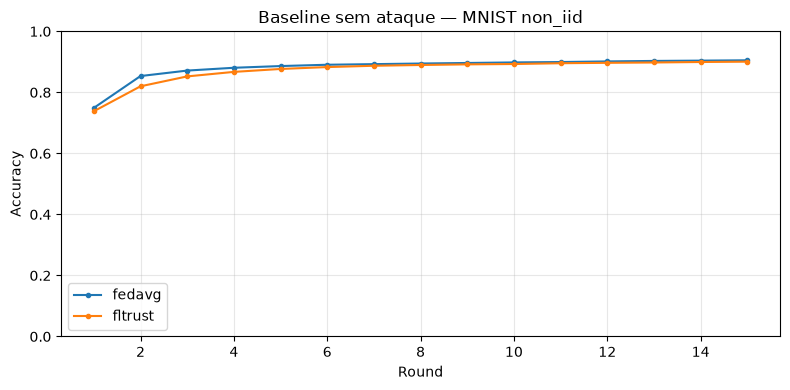

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
for name, accs in results.items():
    ax.plot(range(1, len(accs) + 1), accs, marker='o', markersize=3, label=name)
ax.set_xlabel('Round'); ax.set_ylabel('Accuracy'); ax.set_ylim(0, 1)
ax.set_title(f'Baseline sem ataque — {DATASET.upper()} {SPLIT}')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../results/figures/02_baseline_fedavg.png', bbox_inches='tight')
plt.show()

In [4]:
df = pd.DataFrame({k: v for k, v in results.items()})
df.index.name = 'round'
df.to_csv('../results/tables/02_baseline_fedavg.csv')
df.tail()

,fedavg,fltrust
round,,
10,0.8994,0.8955
11,0.9014,0.8968
12,0.9030,0.8979
13,0.9040,0.8995
14,0.9051,0.9006
